## `make_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `results_methods.py`

In [7]:
import numpy as np 
import fitsio as fio 
import pandas as pd 
import importlib
import matplotlib.pyplot as plt

from pathlib import Path
from pycorr import TwoPointEstimator
from scipy.integrate import simpson

import src.statistics.results_methods as resm
import src.statistics.corrutils as cu
import src.statistics.corrfiles as cf

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

Current approach :

------------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$


In [72]:
importlib.reload(resm)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/results_nonKP_FKP/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT.parent / 'results_2' / f'autos_{desc}_zbin',
    'DESI_NGC' : ROOT / f'autos_{desc}_NGC',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / f'cross_{desc}_zbin',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."

In [73]:
importlib.reload(resm)
tracer = 'LRG'
nz = []
for i in range(1, 5):
    print(f"Computing npz for tracer {tracer} and tomo bin {i}")
    nz.append(
        resm.full_npz_tomo(
            path_dictionary=path_dictionary,
            tracer=tracer,
            tomo_bin=i,
            )
    )

Computing npz for tracer LRG and tomo bin 1


ValueError: No estimators provided.

(-2.0, 8.0)

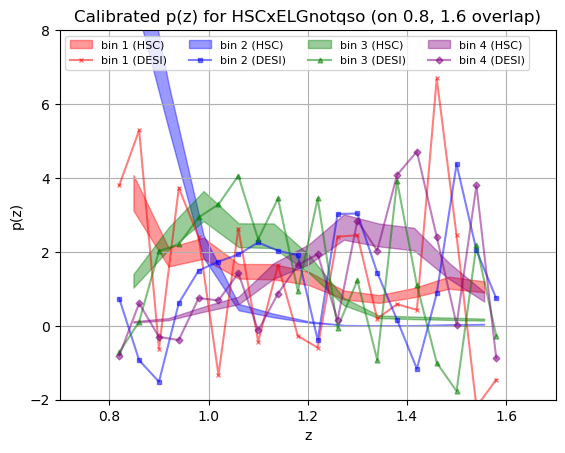

In [71]:
bins_tracer = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
bins_hsc = cf.CorrFileReader(
    path_dictionary['HSC'],
    ).get_bins('HSC')
colors = ['red', 'blue', 'green', 'purple']
markers = ['x', 's', '^', 'D']
zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
mids = tomo_bin_dnnz[mask, 0]

dnnz_list = []
mu_list = []
cov_list = []
ids_to_skip = []
range_tracer = [bins_tracer[0], bins_tracer[-1]]

for i in range(4):
    if max(range_tracer[0], bins_hsc[i]) > min(range_tracer[1], bins_hsc[i+1]):
        ids_to_skip.append(i)
ncurves = 0
for i in range(4):
    if i in ids_to_skip:
        pass
        #continue
    ncurves += 1

    dnnz, mu, cov = resm.hsc_dnnz_error(tomo_bin_dnnz[mask, i+1], mids)

    plt.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colors[i], 
        label=f'bin {i+1} (HSC)',
        alpha=0.4
        )
    plt.plot(
        zval, 
        nz[i]/simpson(nz[i], x=zval), 
        marker=markers[i], 
        markersize=3.5, 
        linestyle='-',  
        alpha=0.5,
        color=colors[i],
        label=f'bin {i+1} (DESI)'
        )
    
plt.xlabel('z')
plt.ylabel('p(z)')
plt.grid()
plt.legend(fontsize=8, ncols=ncurves, loc='upper left')
plt.title(f'Calibrated p(z) for HSCx{tracer} (on {min(bins_tracer):.1f}, {max(bins_tracer):.1f} overlap)')
plt.xlim(min(bins_tracer)-0.1, max(bins_tracer)+0.1)
plt.ylim(-2, 8)

In [ ]:
## Let's check the weights I'm using


Text(0.5, 1.0, 'Bias models as a function of redshift for tracers')

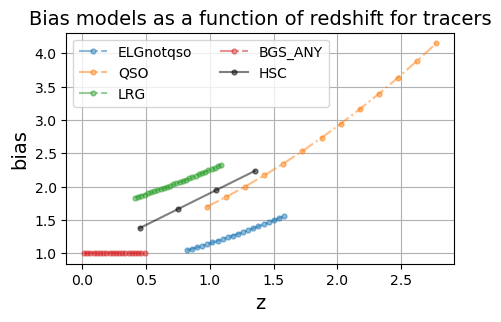

In [64]:
# plot the bias used
importlib.reload(resm)
plt.figure(figsize=(5, 3))
for tracer in ['ELGnotqso', 'QSO', 'LRG', 'BGS_ANY']:
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
    mids_tracer = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    bias = resm.desi_bias_evolution(z=mids_tracer, tracer=tracer)
    plt.plot(
        mids_tracer, 
        bias, 
        marker='o', 
        markersize=3.5, 
        linestyle='-.',  
        alpha=0.5,
        label=f'{tracer}'
    )
mids_hsc = bins_hsc[:-1] + np.diff(bins_hsc) / 2
plt.plot(
    mids_hsc,
    resm.hsc_bias_evolution(z=mids_hsc, b=0.95),
    marker='o',
    markersize=3.5,
    linestyle='-',
    alpha=0.5,
    label='HSC',
    color='black'
)
plt.xlabel('z', fontsize=14)
plt.ylabel('bias', fontsize=14)
plt.grid()
plt.legend(ncols=2, loc='upper left', fontsize=10)
plt.title(f'Bias models as a function of redshift for tracers',  fontsize=14)